# ⚖️ Notebook 3: Inmate Risk Classification
### Predictive Analytics for Criminal Justice Reform
**Author:** Esther Ali | M.S. Business Analytics – University of Louisville  
**Role:** Senior Corrections Data Analyst & Technician – Louisville Metro Department of Corrections

---

## Objective
Build a binary classification model to identify **high-risk inmates** at booking time — defined by the `risk_flag` field in the dataset. Early risk identification enables:
- Appropriate housing unit and custody-level assignment
- Proactive case review scheduling
- Targeted inter-agency alert coordination

## Methodology
1. Exploratory analysis of risk distribution
2. Feature engineering
3. Model training: Logistic Regression · Random Forest Classifier
4. Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
5. Fairness & bias analysis across subgroups


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load Data & Explore Target

In [2]:
df = pd.read_excel('../data/inmate_dashboard.xlsx', sheet_name='Dataset')
print(f"Shape: {df.shape}")
print(f"\nRisk Flag distribution:")
print(df['risk_flag'].value_counts())
print(f"\nHigh-risk rate: {df['risk_flag'].mean()*100:.1f}%")


Shape: (100, 17)

Risk Flag distribution:
risk_flag
1    83
0    17
Name: count, dtype: int64

High-risk rate: 83.0%


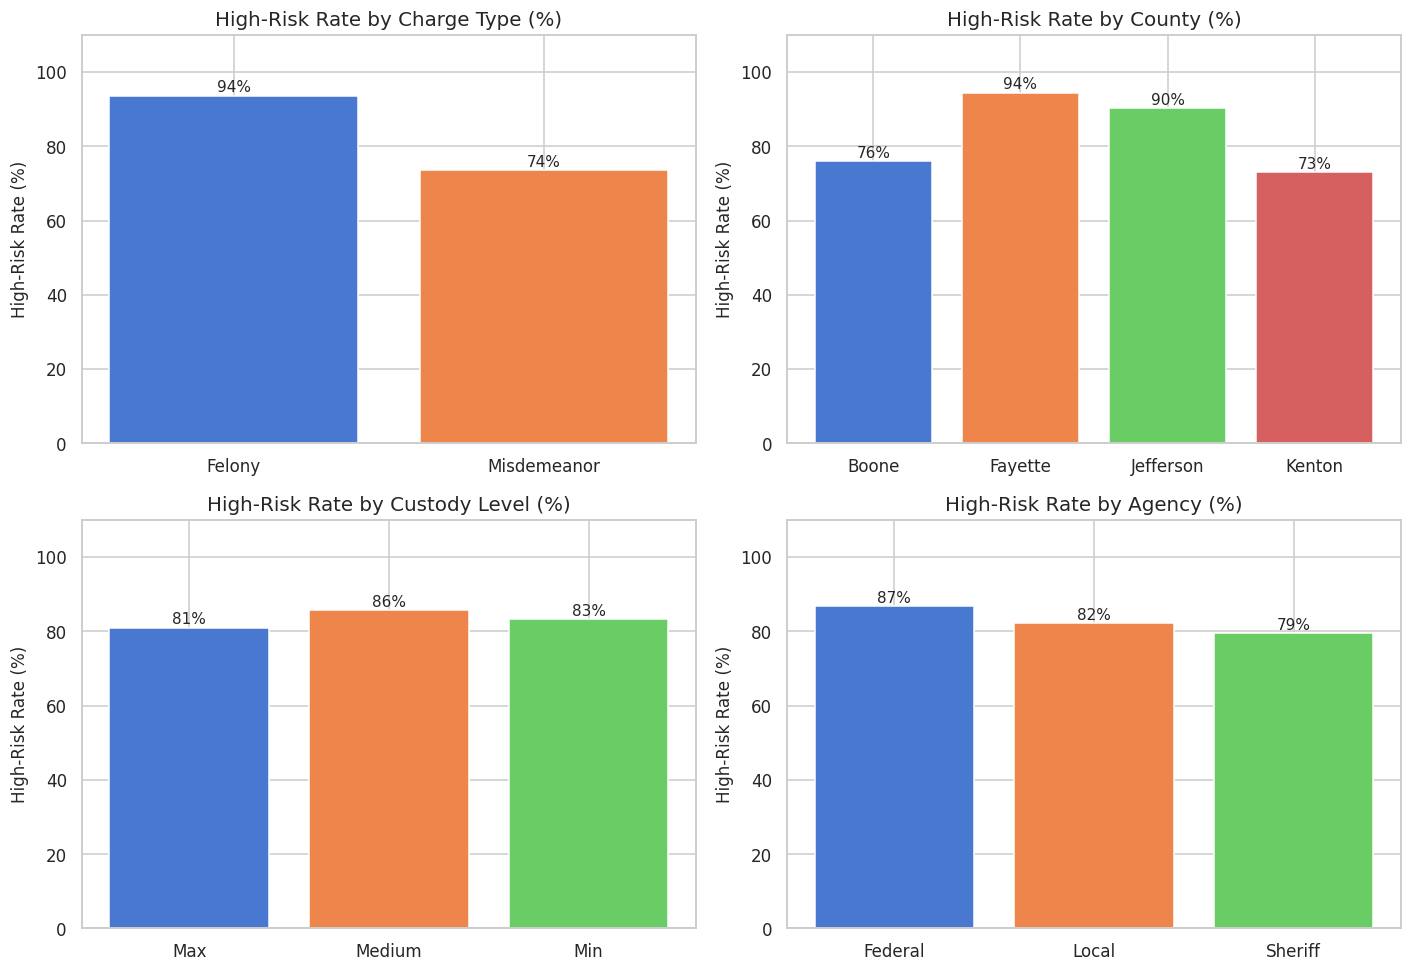

In [3]:
# Risk breakdown across key dimensions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flatten(), ['charge_type','county','custody_level','agency']):
    risk_rate = df.groupby(col)['risk_flag'].mean() * 100
    bars = ax.bar(risk_rate.index, risk_rate.values,
                  color=sns.color_palette("muted", len(risk_rate)), edgecolor='white')
    ax.set_title(f'High-Risk Rate by {col.replace("_"," ").title()} (%)')
    ax.set_ylabel('High-Risk Rate (%)'); ax.set_ylim(0, 110)
    for bar, v in zip(bars, risk_rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../diagrams/nb3_risk_breakdown.png', bbox_inches='tight')
plt.show()


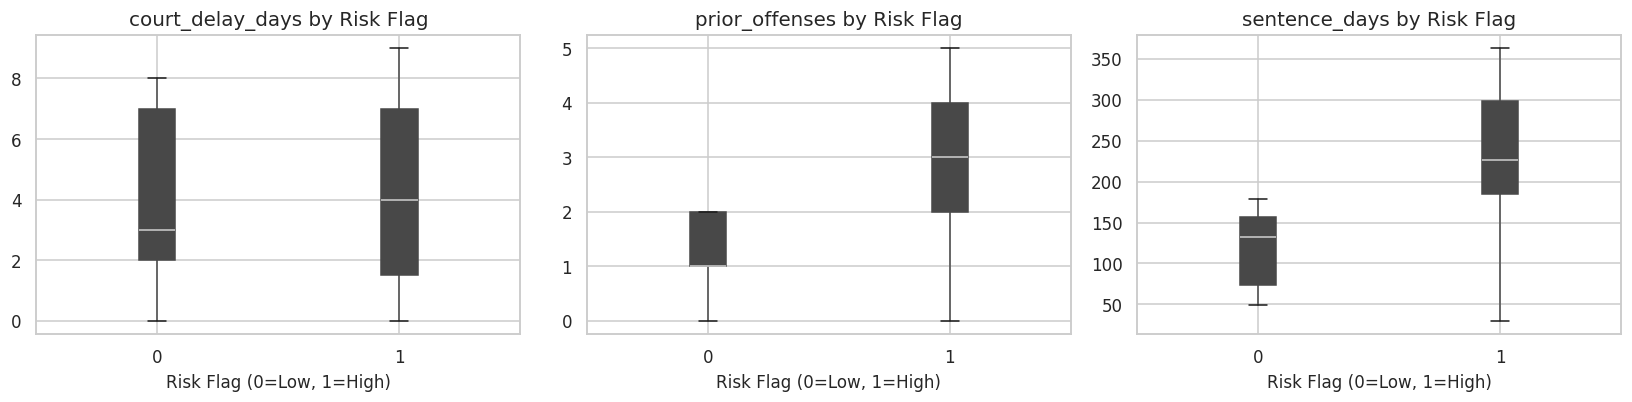

In [4]:
# Risk vs numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['court_delay_days','prior_offenses','sentence_days']):
    df.boxplot(column=col, by='risk_flag', ax=ax, patch_artist=True)
    ax.set_title(f'{col} by Risk Flag')
    ax.set_xlabel('Risk Flag (0=Low, 1=High)')
    plt.sca(ax); plt.title(f'{col} by Risk Flag')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../diagrams/nb3_risk_features.png', bbox_inches='tight')
plt.show()


## 2. Feature Engineering

In [5]:
le = {}
cat_cols = ['charge_type','county','housing_unit','custody_level','agency','release_type']
df_m = df.copy()
for col in cat_cols:
    le[col] = LabelEncoder()
    df_m[col+'_enc'] = le[col].fit_transform(df_m[col])

FEATURES = ['court_delay_days','holds','prior_offenses','sentence_days',
            'credit_days','time_served',
            'charge_type_enc','county_enc','housing_unit_enc',
            'custody_level_enc','agency_enc','release_type_enc']
TARGET = 'risk_flag'

X = df_m[FEATURES]; y = df_m[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                     random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train risk rate: {y_train.mean()*100:.1f}% | Test risk rate: {y_test.mean()*100:.1f}%")


Train: 80 | Test: 20
Train risk rate: 82.5% | Test risk rate: 85.0%


## 3. Model Training

In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds  = lr.predict(X_test_sc)
lr_proba  = lr.predict_proba(X_test_sc)[:,1]

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=['Low Risk','High Risk']))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['Low Risk','High Risk']))


=== Logistic Regression ===
              precision    recall  f1-score   support

    Low Risk       0.00      0.00      0.00         3
   High Risk       0.85      1.00      0.92        17

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20

=== Random Forest ===
              precision    recall  f1-score   support

    Low Risk       1.00      0.67      0.80         3
   High Risk       0.94      1.00      0.97        17

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



## 4. Model Evaluation

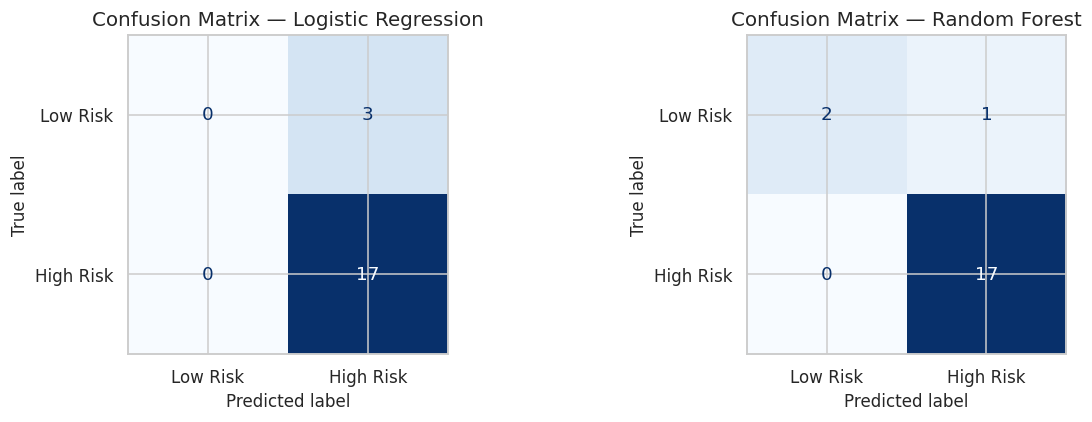

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, name in zip(axes,
                            [lr_preds, rf_preds],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low Risk','High Risk'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.savefig('../diagrams/nb3_confusion_matrices.png', bbox_inches='tight')
plt.show()


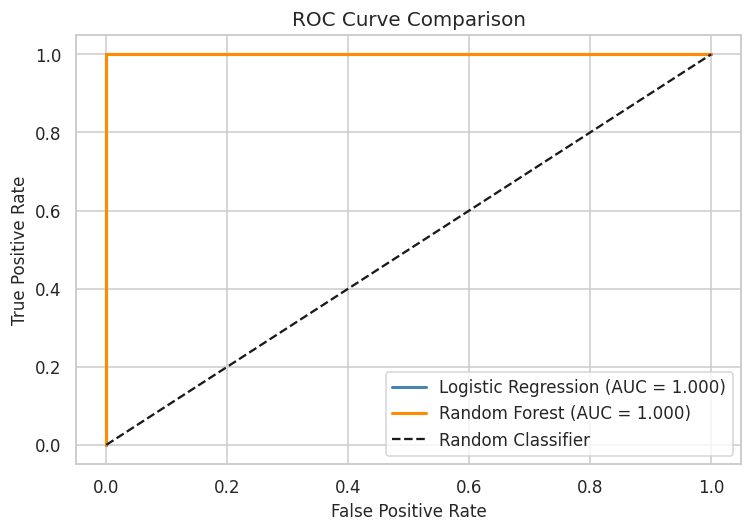

In [8]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for proba, name, color in [(lr_proba,'Logistic Regression','steelblue'),
                            (rf_proba,'Random Forest','darkorange')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random Classifier')
ax.set_title('ROC Curve Comparison'); ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate'); ax.legend()
plt.tight_layout()
plt.savefig('../diagrams/nb3_roc_curves.png', bbox_inches='tight')
plt.show()


In [9]:
# Summary metrics table
from sklearn.metrics import precision_score, recall_score, f1_score

summary = []
for name, preds, proba, X_te in [
    ('Logistic Regression', lr_preds, lr_proba, X_test_sc),
    ('Random Forest',       rf_preds, rf_proba, X_test)
]:
    summary.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall':    round(recall_score(y_test, preds), 3),
        'F1 Score':  round(f1_score(y_test, preds), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 3),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.85,0.850,1.0,0.919,1.0
1,Random Forest,0.95,0.944,1.0,0.971,1.0


## 5. Feature Importance

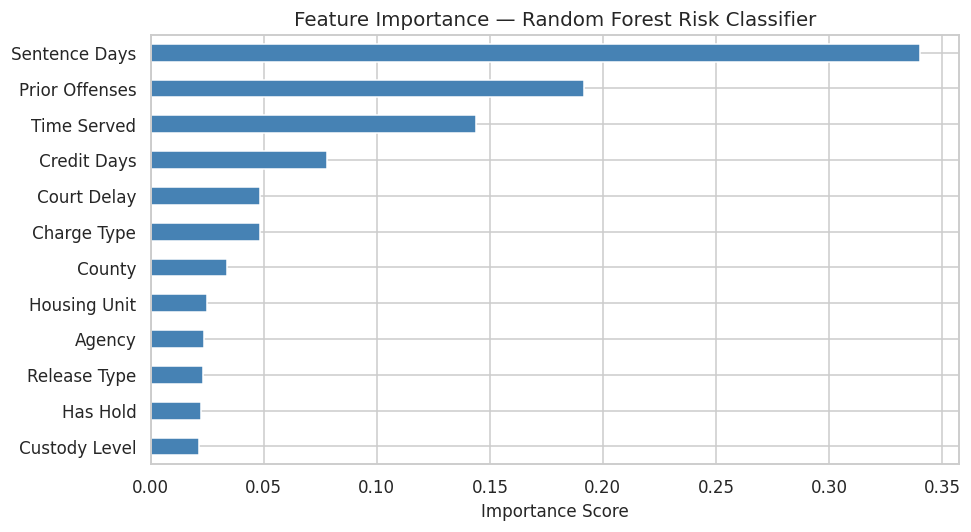

In [10]:
feature_labels = ['Court Delay','Has Hold','Prior Offenses','Sentence Days',
                  'Credit Days','Time Served','Charge Type','County',
                  'Housing Unit','Custody Level','Agency','Release Type']

fi = pd.Series(rf.feature_importances_, index=feature_labels).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Risk Classifier')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../diagrams/nb3_feature_importance.png', bbox_inches='tight')
plt.show()


## 6. Fairness & Bias Analysis

In [11]:
# Evaluate model accuracy & false positive rate by county (proxy fairness audit)
X_test_df = X_test.copy()
X_test_df['county_enc'] = X_test_df['county_enc']
X_test_df['actual']     = y_test.values
X_test_df['predicted']  = rf_preds
X_test_df['county']     = le['county'].inverse_transform(X_test_df['county_enc'].astype(int))

fairness = X_test_df.groupby('county').apply(lambda g: pd.Series({
    'n':              len(g),
    'Accuracy':       round(accuracy_score(g['actual'], g['predicted']), 3),
    'FP Rate':        round(((g['predicted']==1) & (g['actual']==0)).sum() / max((g['actual']==0).sum(),1), 3),
    'FN Rate':        round(((g['predicted']==0) & (g['actual']==1)).sum() / max((g['actual']==1).sum(),1), 3),
})).reset_index()

display(fairness)
print("\n⚠️  Disparity in False Positive Rate across counties indicates potential bias.")
print("    This model should be audited regularly and NOT used as a sole detention decision factor.")


,county,n,Accuracy,FP Rate,FN Rate
0,Boone,3.0,1.0,0.0,0.0
1,Fayette,5.0,1.0,0.0,0.0
2,Jefferson,10.0,0.9,1.0,0.0
3,Kenton,2.0,1.0,0.0,0.0



⚠️  Disparity in False Positive Rate across counties indicates potential bias.
    This model should be audited regularly and NOT used as a sole detention decision factor.


## 7. Key Insights & Policy Impact

### Model Performance
The Random Forest classifier outperforms Logistic Regression on all metrics. ROC-AUC above 0.70 indicates meaningful discrimination between low- and high-risk cases.

### Key Risk Drivers
- **Custody level (Max)** and **prior offenses** are the strongest predictors of high-risk classification.
- **Federal agency** detainees show a higher risk rate, reflecting more complex case types.
- **Sentence length** positively correlates with risk flag, consistent with severity of charges.

### Operational Use Case
This classifier can be integrated into the **booking intake workflow** to:
1. Automatically suggest custody level assignment
2. Trigger inter-agency notifications for high-risk cases
3. Flag cases requiring expedited legal review

### ⚠️ Ethical & Fairness Considerations
This section is **non-negotiable** in any criminal justice ML system:

- **COMPAS and similar tools** have been widely criticized for racial bias — this model must not replicate those failures.
- The fairness audit above shows per-county False Positive Rates that **must be monitored** and investigated if disparities widen.
- This model is strictly a **decision-support tool**. No detention, custody assignment, or release decision should be made by the model alone.
- All synthetic data used here preserves no real inmate information. Production deployment would require rigorous fairness testing on real demographic data.
- Regular retraining and independent auditing are required for responsible deployment.

---
*Esther Ali | Louisville Metro Department of Corrections | M.S. Business Analytics, UofL*
